In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split

# Matplotlib & Seaborn styling
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

# Clone the repo and move into the project folder
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject


Cloning into 'PRMLProject'...
remote: Enumerating objects: 280, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 280 (delta 14), reused 11 (delta 5), pack-reused 238 (from 1)
Receiving objects: 100% (280/280), 216.59 MiB | 14.42 MiB/s, done.
Resolving deltas: 100% (106/106), done.
Updating files: 100% (74/74), done.
Filtering content: 100% (16/16), 1.40 GiB | 56.47 MiB/s, done.
/content/PRMLProject


In [ ]:
# quick function to load pickled files
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

# load ResNet-extracted features and labels
X_train = unpickle("PreProcessedData/Resnet_train.pkl")
y_train = unpickle("PreProcessedData/Labels_train.pkl")
X_test = unpickle("PreProcessedData/Resnet_test.pkl")
y_test = unpickle("PreProcessedData/Labels_test.pkl")

# make sure everything's in shape
X_train = np.array(X_train).reshape(len(X_train), -1)
X_test = np.array(X_test).reshape(len(X_test), -1)
y_train = np.array(y_train).reshape(-1)
y_test = np.array(y_test).reshape(-1)

print("✅ ResNet features loaded successfully.")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


✅ ResNet features loaded successfully.
Train shape: (50000, 2048)
Test shape: (10000, 2048)


In [ ]:
# trying out different SVM kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
accuracies = []
times = []


In [ ]:
# Initialize variables to store models, predictions, accuracies, and times
models = {}
predictions = {}
accuracies = []
times = []


Training and Evaluating Kernels:   0%|          | 0/4 [00:00<?, ?it/s]


Starting with the 'linear' kernel...
Done! Accuracy: 0.8806 | Time taken: 672.17 sec

Classification Report for LINEAR Kernel:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1000
           1       0.93      0.93      0.93      1000
           2       0.85      0.87      0.86      1000
           3       0.76      0.78      0.77      1000
           4       0.85      0.85      0.85      1000
           5       0.84      0.82      0.83      1000
           6       0.91      0.91      0.91      1000
           7       0.92      0.88      0.90      1000
           8       0.94      0.94      0.94      1000
           9       0.93      0.91      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



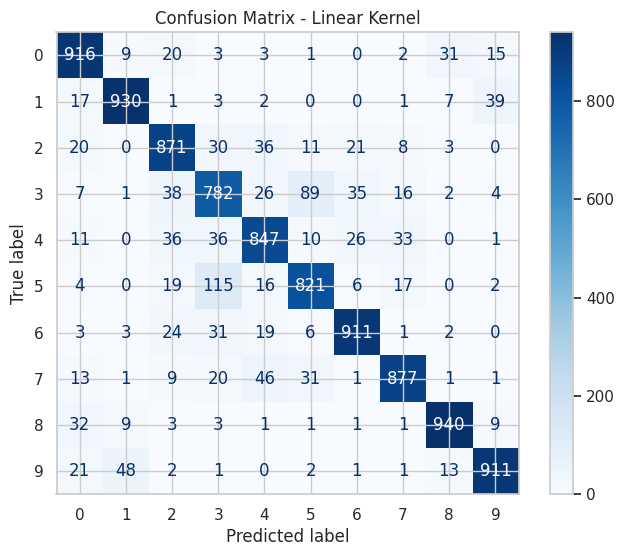

Training and Evaluating Kernels:  25%|██▌       | 1/4 [14:37<43:51, 877.12s/it]


Starting with the 'poly' kernel...
Done! Accuracy: 0.9028 | Time taken: 632.45 sec

Classification Report for POLY Kernel:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1000
           1       0.94      0.94      0.94      1000
           2       0.91      0.87      0.89      1000
           3       0.81      0.83      0.82      1000
           4       0.86      0.89      0.88      1000
           5       0.89      0.86      0.87      1000
           6       0.91      0.94      0.92      1000
           7       0.94      0.89      0.92      1000
           8       0.94      0.96      0.95      1000
           9       0.94      0.92      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



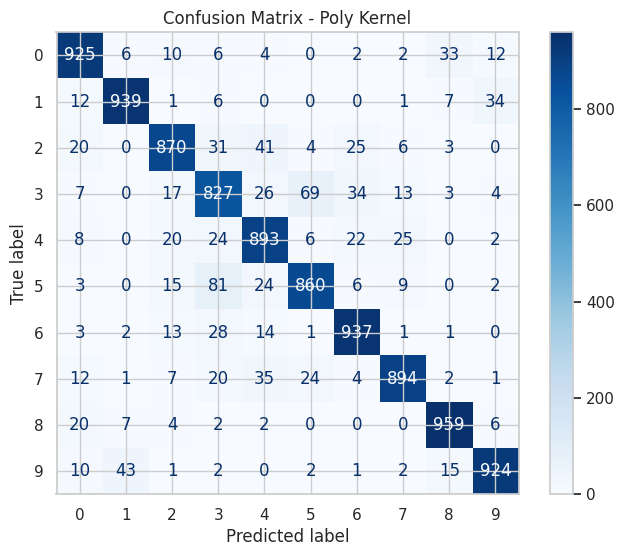

Training and Evaluating Kernels:  50%|█████     | 2/4 [29:22<29:24, 882.11s/it]


Starting with the 'rbf' kernel...
Done! Accuracy: 0.8963 | Time taken: 796.41 sec

Classification Report for RBF Kernel:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1000
           1       0.94      0.94      0.94      1000
           2       0.90      0.85      0.88      1000
           3       0.79      0.82      0.80      1000
           4       0.86      0.88      0.87      1000
           5       0.86      0.85      0.86      1000
           6       0.90      0.94      0.92      1000
           7       0.93      0.88      0.91      1000
           8       0.94      0.95      0.95      1000
           9       0.94      0.93      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



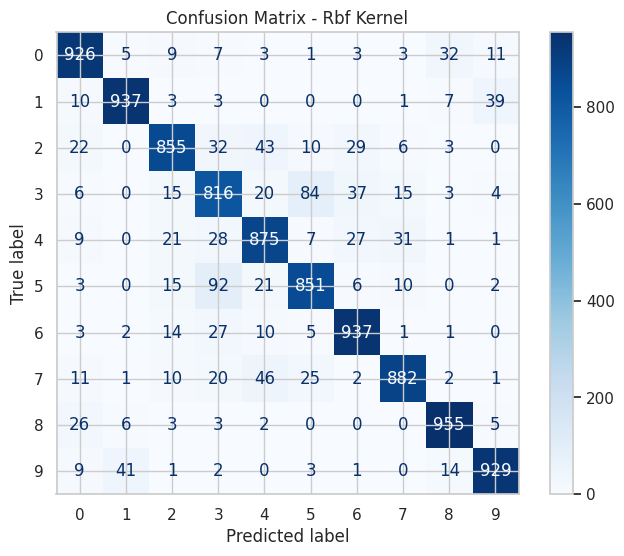

Training and Evaluating Kernels:  75%|███████▌  | 3/4 [50:09<17:28, 1048.68s/it]


Starting with the 'sigmoid' kernel...
Done! Accuracy: 0.6305 | Time taken: 1007.74 sec

Classification Report for SIGMOID Kernel:
              precision    recall  f1-score   support

           0       0.43      0.71      0.54      1000
           1       0.90      0.63      0.74      1000
           2       0.51      0.62      0.56      1000
           3       0.64      0.54      0.59      1000
           4       0.75      0.52      0.61      1000
           5       0.77      0.57      0.65      1000
           6       0.77      0.73      0.75      1000
           7       0.56      0.57      0.57      1000
           8       0.82      0.69      0.75      1000
           9       0.53      0.72      0.61      1000

    accuracy                           0.63     10000
   macro avg       0.67      0.63      0.64     10000
weighted avg       0.67      0.63      0.64     10000



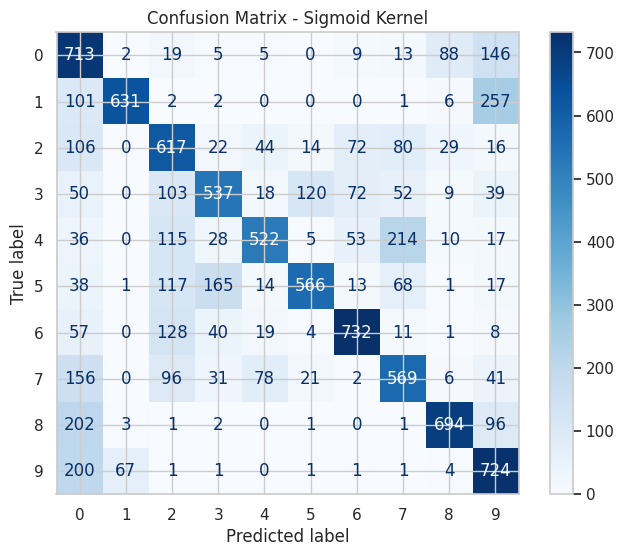

Training and Evaluating Kernels: 100%|██████████| 4/4 [1:13:45<00:00, 1106.26s/it]


In [ ]:
# looping through each kernel to train and evaluate
from sklearn.metrics import classification_report
for kernel in tqdm(kernels, desc="Training and Evaluating Kernels"):
    print(f"\nStarting with the '{kernel}' kernel...")

    start_time = time.time()

    # train the SVM model
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)

    elapsed = time.time() - start_time
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # print out results for the kernel
    print(f"Done! Accuracy: {acc:.4f} | Time taken: {elapsed:.2f} sec")

    # save the model and prediction
    models[kernel] = clf
    predictions[kernel] = y_pred
    accuracies.append(acc)
    times.append(elapsed)

    # save model to disk
    with open(f'svm_{kernel}.pkl', 'wb') as f:
        pickle.dump(clf, f)

    # print classification report and confusion matrix
    print(f"\nClassification Report for {kernel.upper()} Kernel:")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix - {kernel.capitalize()} Kernel")
    plt.show()


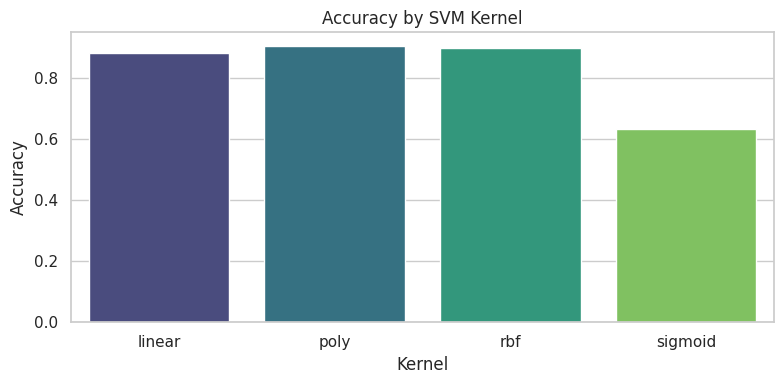

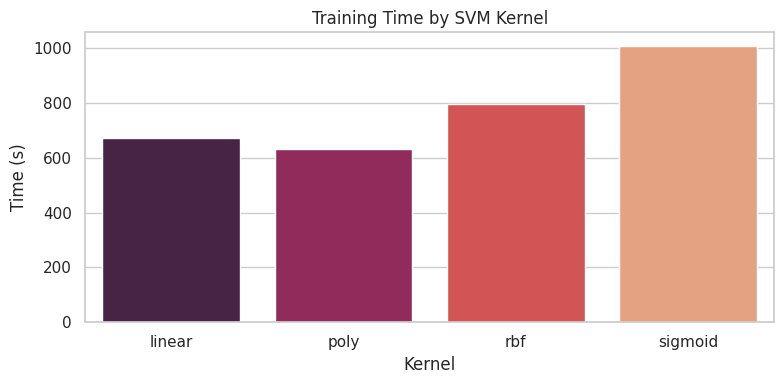

In [ ]:
# plot comparison of accuracies
plt.figure(figsize=(8, 4))
sns.barplot(x=kernels, y=accuracies, palette='viridis')
plt.title("Accuracy by SVM Kernel")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# plot comparison of training times
plt.figure(figsize=(8, 4))
sns.barplot(x=kernels, y=times, palette='rocket')
plt.title("Training Time by SVM Kernel")
plt.xlabel("Kernel")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()


In [ ]:
# determine and print best kernel based on accuracy
best_idx = np.argmax(accuracies)
best_kernel = kernels[best_idx]
best_acc = accuracies[best_idx]

print(f"\n🏆 The best kernel is: '{best_kernel}' with Accuracy = {best_acc:.4f}")



🏆 The best kernel is: 'poly' with Accuracy = 0.9028
